In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Ура, картинка успешно загружена!
Подходящие контуры монет не найдены!


<Axes: >

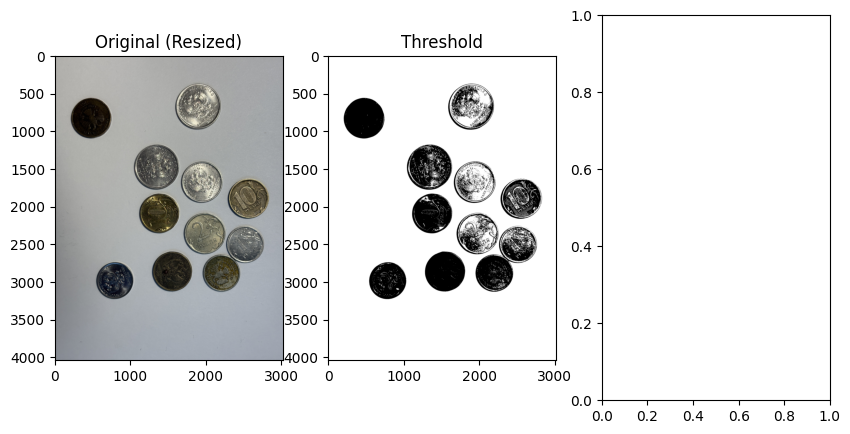

In [15]:


# 1. Загружаем тестовое фото одиночной монеты
# Замени '1r_v1.jpg' на имя любого своего файла из папки singles

# Читаем файл как массив байт
img_array = np.fromfile(img_path, np.uint8)
# Декодируем массив в изображение OpenCV
img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

# Проверяем, что картинка точно загрузилась
if img is None:
    print(f"Ошибка! Не удалось загрузить файл по пути: {img_path}")
    print("Проверь, правильно ли написано имя файла и его расширение (.JPG или .jpg)")
else:
    # Если всё ок, переводим в RGB и идем дальше
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print("Ура, картинка успешно загружена!")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. Изменяем размер для удобства обработки (например, уменьшим в 4 раза)
h, w = img.shape[:2]
new_w = 1024
new_h = int(h * (new_w / w))
img_resized = cv2.resize(img_rgb, (w, h), interpolation=cv2.INTER_AREA)

# 3. Переводим в Grayscale и размываем
gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
# blurred = cv2.GaussianBlur(gray, (11, 11), 0)

# 4. Бинаризация (так как фон белый, а монета темнее, инвертируем порог)
# Все, что темнее фона, станет белым (монета), а фон — черным
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 5. Находим контуры на бинаризованном изображении
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Отфильтруем контуры: оставим только те, у которых площадь меньше 80% от всего кадра
# Это мгновенно отсечет рамку самого кадра
img_area = img_resized.shape[0] * img_resized.shape[1]
valid_contours = [c for c in contours if cv2.contourArea(c) < 0.8 * img_area]

if len(valid_contours) > 0:
    # Берем самый большой контур ИЗ ОСТАВШИХСЯ (это теперь точно монета)
    c = max(valid_contours, key=cv2.contourArea)

    # Получаем ограничивающий прямоугольник
    x, y, w, h = cv2.boundingRect(c)

    # Делаем квадратный кроп с небольшим запасом в 15 пикселей
    side = max(w, h) + 15
    cx, cy = x + w // 2, y + h // 2

    x1 = max(0, cx - side // 2)
    y1 = max(0, cy - side // 2)
    x2 = min(img_resized.shape[1], cx + side // 2)
    y2 = min(img_resized.shape[0], cy + side // 2)

    coin_crop = img_resized[y1:y2, x1:x2]

    # Показываем результат
    plt.figure(figsize=(5, 5))
    plt.title("Вырезанная монета (Исправлено)")
    plt.imshow(coin_crop)
    plt.axis('off')
    plt.show()

    # Выведем размер для контроля, он должен быть в районе 200-400 пикселей
    print(f"Размер вырезанного квадрата: {coin_crop.shape[:2]}")
else:
    print("Подходящие контуры монет не найдены!")


# Отобразим, что получилось на этом этапе
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.title("Original (Resized)")
plt.imshow(img_resized)

plt.subplot(1, 3, 2)
plt.title("Threshold")
plt.imshow(thresh, cmap='gray')

plt.subplot(1, 3, 3)


In [3]:
img_path = 'D:/практика 2 курс/university 2nd year practice/raw/scenes/IMG_3898.JPG'

image = cv2.imread(img_path)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

gray = cv2.GaussianBlur(gray, (9, 9), 2)

#Обнаружение для нескольких монет

# circles = cv2.HoughCircles(
#     gray,
#     cv2.HOUGH_GRADIENT,
#     dp=1,
#     minDist=560,
#     param1=130,
#     param2=20,
#     minRadius=280,
#     maxRadius=300
# )

#Обнаружение для одной монеты

circles = cv2.HoughCircles(
    gray,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=560,
    param1=130,
    param2=20,
    minRadius=280,
    maxRadius=300
)

circles = np.uint16(np.around(circles))

img_circles = img.copy()

if circles is not None:
    circles = np.uint16(np.around(circles))

    # Рисуем каждый найденный круг
    for i in circles[0, :]:
        # Рисуем окружность (контур круга)
        cv2.circle(img_circles, (i[0], i[1]), i[2], (0, 255, 0), 5)

        # Рисуем центр круга
        cv2.circle(img_circles, (i[0], i[1]), 2, (0, 0, 255), 1)

plt.imshow(img_circles)

error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [ ]:
coins = []

for c in circles[0]:
    x, y, r = c

    crop = image[
        max(0, y-r):y+r,
        max(0, x-r):x+r
    ]

    coins.append(crop)